<a href="https://colab.research.google.com/github/marcohinojosag/IA_MKTR/blob/jma-preproces/cod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Importación de librerias y carga del dataset
Quien necesita descargar en 2025, las APIs son el futuro 🗣🗣🗣

In [117]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from kagglehub import KaggleDatasetAdapter

In [118]:
# Sets path
test_path = "aps_failure_test_set.csv"
train_path = "aps_failure_training_set.csv"

# Load the latest version
test = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/aps-failure-at-scania-trucks-data-set",
  test_path,
)

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/aps-failure-at-scania-trucks-data-set",
  train_path,
)

Using Colab cache for faster access to the 'aps-failure-at-scania-trucks-data-set' dataset.
Using Colab cache for faster access to the 'aps-failure-at-scania-trucks-data-set' dataset.


# 1. Analisis del dataset


In [119]:
# Muestra de los datos
print(df.head(5))

  class  aa_000 ab_000      ac_000 ad_000 ae_000 af_000 ag_000 ag_001 ag_002  \
0   neg   76698     na  2130706438    280      0      0      0      0      0   
1   neg   33058     na           0     na      0      0      0      0      0   
2   neg   41040     na         228    100      0      0      0      0      0   
3   neg      12      0          70     66      0     10      0      0      0   
4   neg   60874     na        1368    458      0      0      0      0      0   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790  405298  347188  286954  311560  433954   1218      0   

  eg_000  
0      0  
1      0  

In [120]:
# Tamaño del dataset
print(df.shape)

(60000, 171)


Como que 60k filas 💀, que diga...

Descripcion de las columnas:
- clase: "neg" indica fallo en el sistema APS, "pos" todo en orden. (se renombra por palabra reservada)
- aa_000, ab_000, ac_000, ..., eg_000: atributos de entrada, sin un significado en particular (anonimos)

In [121]:
# Columnas del dataset
df.rename(columns={'class': 'clase'}, inplace=True)
df.columns

Index(['clase', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000',
       'ag_000', 'ag_001', 'ag_002',
       ...
       'ee_002', 'ee_003', 'ee_004', 'ee_005', 'ee_006', 'ee_007', 'ee_008',
       'ee_009', 'ef_000', 'eg_000'],
      dtype='object', length=171)

In [122]:
# Cantidad de elementos vacios por cada columna
cant_vacios = (df == "na").sum()
cant_vacios = cant_vacios[cant_vacios > 0]
print(cant_vacios)

ab_000    46329
ac_000     3335
ad_000    14861
ae_000     2500
af_000     2500
          ...  
ee_007      671
ee_008      671
ee_009      671
ef_000     2724
eg_000     2723
Length: 169, dtype: int64


In [123]:
# Cantidad de positivos y negativos del dataset
cant_neg = len(df[df.clase == 'neg'])
cant_pos = len(df[df.clase == 'pos'])
print(f"Negativos: {cant_neg}, Positivos: {cant_pos}")

Negativos: 59000, Positivos: 1000


# 2. Preprocesamiento del dataset

Por la cantidad de elementos "na" que contienen algunas columnas se eliminaran las que tengan cierto porcentaje de este dato, asi se mantendran las columnas con mas contenido. Estrategia tomada de https://www.kaggle.com/code/humeranaz911/aps-fault-detection

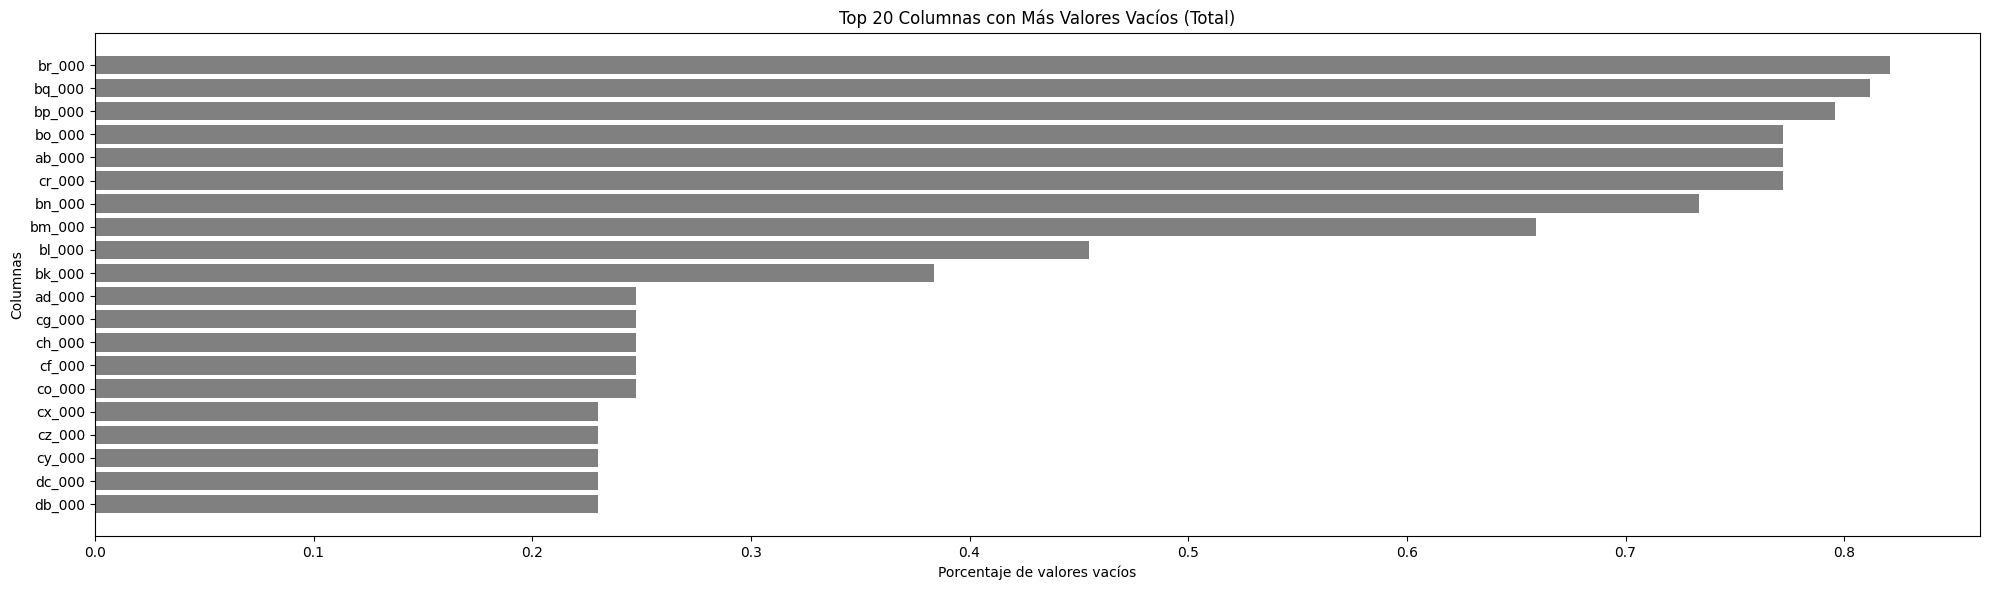

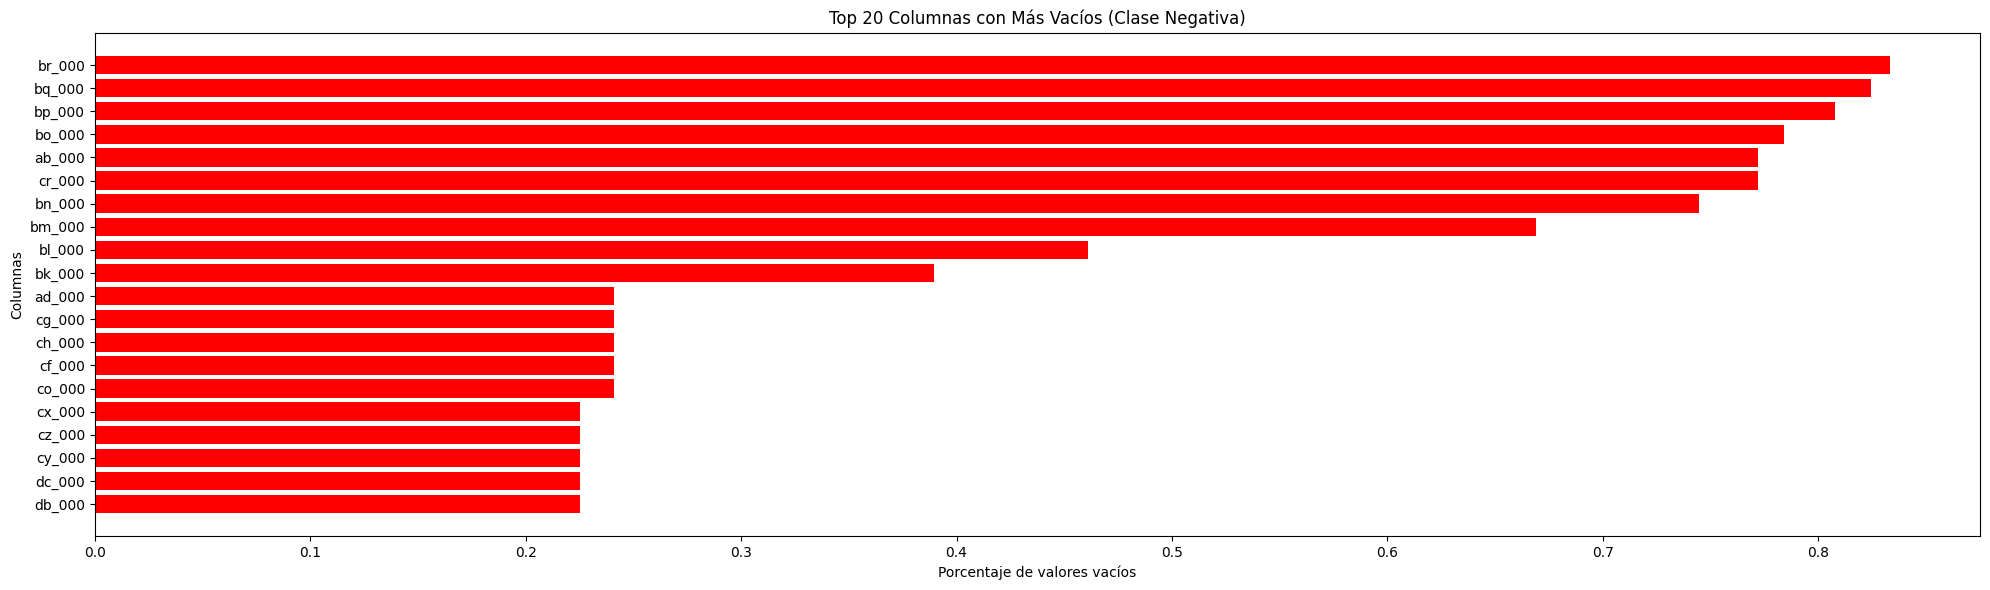

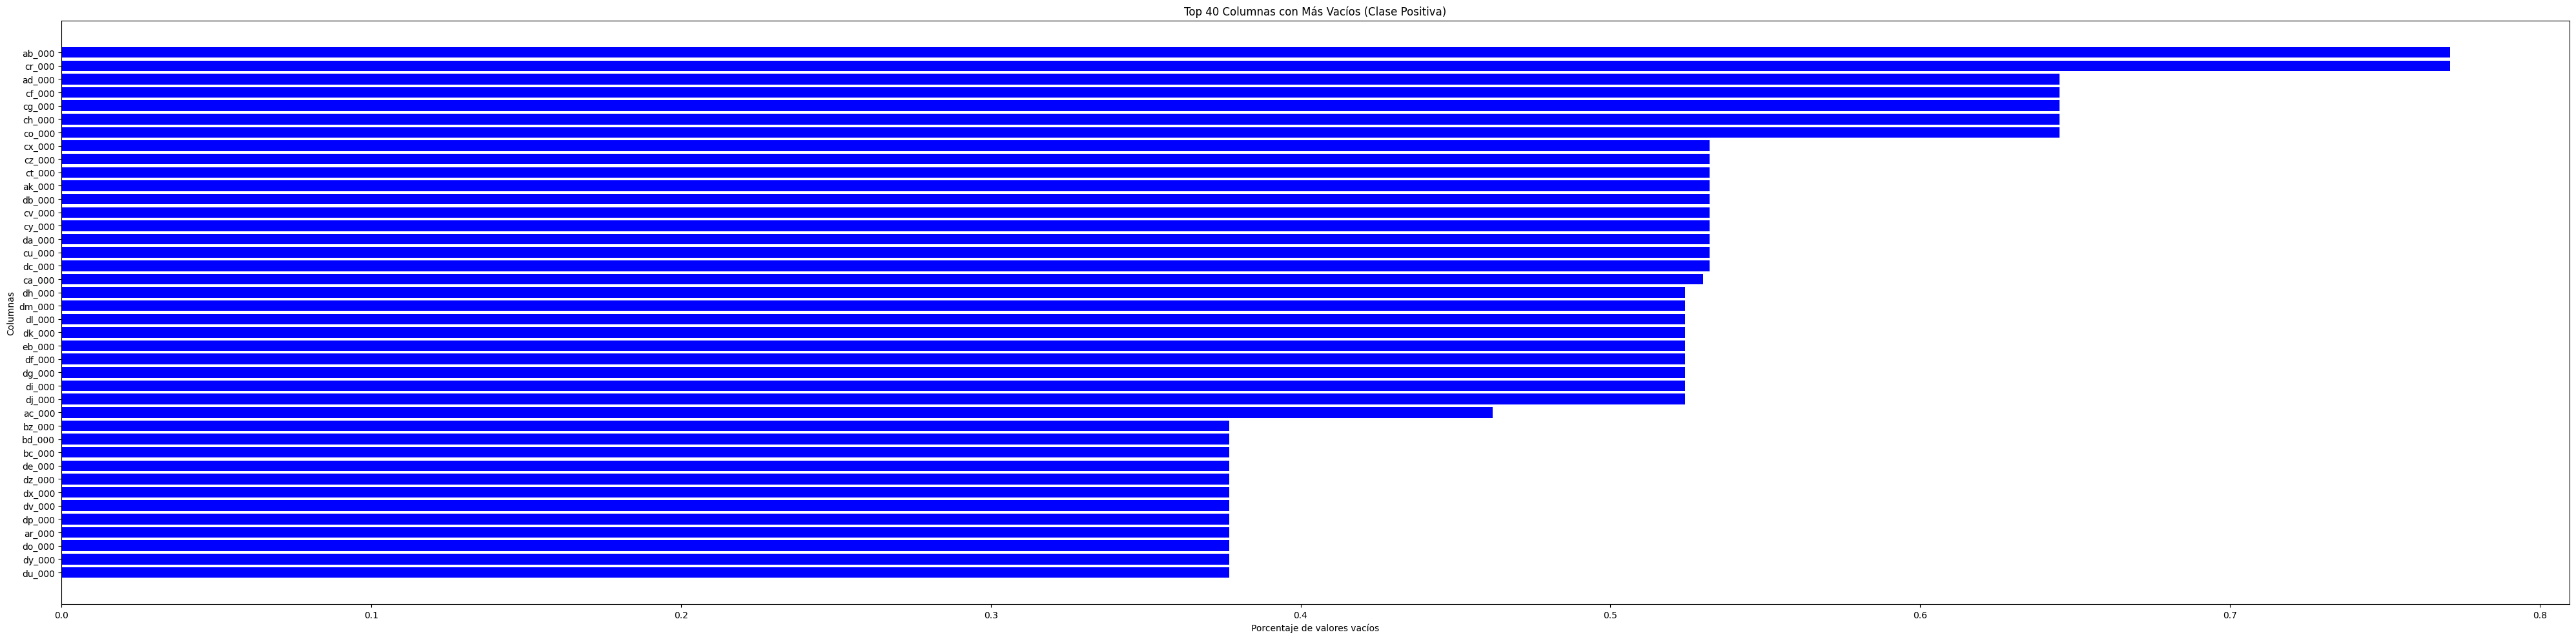

In [124]:
# separacion en dos dataframes de positivo y negativo
df_neg = df[df['clase'] == 'neg']
df_pos = df[df['clase'] == 'pos']

# obtencion de cantidad de elementos vacios por tipo
cv = (df == "na").sum()/len(df)
cv_neg = (df_neg == "na").sum()/cant_neg
cv_pos = (df_pos == "na").sum()/cant_pos

# Columnas más vacias por clasificación
top = cv.sort_values(ascending=False).head(20)
top_neg = cv_neg.sort_values(ascending=False).head(20)
top_pos = cv_pos.sort_values(ascending=False).head(40)

# Top 20 columnas con más vacíos en total
plt.figure(figsize=(20, 6))
plt.barh(top.index[::-1], top.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top 20 Columnas con Más Valores Vacíos (Total)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

# Top 20 columnas con más vacíos en clase negativa
plt.figure(figsize=(20, 6))
plt.barh(top_neg.index[::-1], top_neg.values[::-1], color='red')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top 20 Columnas con Más Vacíos (Clase Negativa)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

# Top 30 columnas con más vacíos en clase positiva
plt.figure(figsize=(40, 10))
plt.barh(top_pos.index[::-1], top_pos.values[::-1], color='blue')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top 40 Columnas con Más Vacíos (Clase Positiva)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

De las graficas se observa lo siguiente:
- En el dataset completo las columnas con más elementos vacios son br_000, bq_000, bp_000, bo_000, ab_000, cr_000, bn_000 y bm_000. (porcentaje mayor al 50%)
- En el sub dataset de la clase negativa son: br_000, bq_000, bp_000, bo_000, ab_000, cr_000, bn_000 y bm_000. (porcentaje mayor al 50%)
- En el sub dataset de la clase positiva son: ab_000, cr_000, etc.

El dataset completo y el sub dataset negativo se corresponden ya que este ultimo contiene la mayor parte de los datos (59k de 60k [98.333%]), por parte del subdataset positivo hay varias columnas con un porcentaje de "na" superior al 50%, como este conjunto supone solo 1000 filas hay que conservar la mayor cantidad posible, se emplea el siguiente codigo para eliminar columnas que quiten información de entrenamiento.

In [125]:
# Umbrales para cada clase (ajustar)
umbral_neg = 0.75
umbral_pos = 0.2

# Filtrado de las columnas con más del "umbral" porcentaje de "na"
columnas_rm_neg = cv_neg[cv_neg > umbral_neg].index
columnas_rm_pos = cv_pos[cv_pos > umbral_pos].index

# Set con las columnas a eliminar
columnas_rm = set(columnas_rm_neg).union(set(columnas_rm_pos))

# Eliminación de las columnas filtradas y filas con na
df_clean = df.drop(columns=columnas_rm)
df_clean = df_clean[~df_clean.isin(["na"]).any(axis=1)]

In [126]:
# Cantidad de positivos y negativos del dataset
cant_neg = len(df_clean[df_clean.clase == 'neg'])
cant_pos = len(df_clean[df_clean.clase == 'pos'])
print(f"Negativos: {cant_neg}, Positivos: {cant_pos}")

Negativos: 12094, Positivos: 877


Con esto se lograron eliminar las columnas que eliminarian la mayor cantidad de datos de entrenamiento, y tambien se eliminaron las filas con valor "na" dentro, a partir de aca se puede hacer el tratamiento de datos como conversion a tipo de dato numerico, normalización, etc.

In [127]:
# Conversion de todas las columnas (excepto clase) a tipo de dato numerico
df_clean_numeric = df_clean.drop(columns=["clase"])
df_clean_numeric = df_clean_numeric.apply(pd.to_numeric, errors="coerce")

# Conversion de la columna "clase" a 0 para "neg" y 1 para "pos"
df_clean["clase"] = df_clean["clase"].map({"neg": 0, "pos": 1})

# Union de las columnas tratadas
df_clean = pd.concat([df_clean["clase"], df_clean_numeric], axis=1)

print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 12971 entries, 0 to 59998
Columns: 107 entries, clase to ee_009
dtypes: float64(5), int64(102)
memory usage: 10.7 MB
None


In [128]:
from sklearn.preprocessing import MinMaxScaler

# Conversion de los datos a float (decimales)
df_clean = df_clean.astype(float)

# Separación de la columna "clase" y las demas
x = df_clean.drop(columns=["clase"])
y = df_clean["clase"]

# Normalización de los datos
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

# Datos de entranamiento
x_train = pd.DataFrame(x_scaled, columns=x.columns)
y_train = y

print("___________________________")
print("Entrada de entrenamiento")
print(x_train.info())
print("___________________________")
print("Salida de entrenamiento")
print(y_train.info())

___________________________
Entrada de entrenamiento
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12971 entries, 0 to 12970
Columns: 106 entries, aa_000 to ee_009
dtypes: float64(106)
memory usage: 10.5 MB
None
___________________________
Salida de entrenamiento
<class 'pandas.core.series.Series'>
Index: 12971 entries, 0 to 59998
Series name: clase
Non-Null Count  Dtype  
--------------  -----  
12971 non-null  float64
dtypes: float64(1)
memory usage: 202.7 KB
None


# 2.1 Replicacion del mismo pre procesamiento para el dataframe de test

In [129]:
test.rename(columns={'class': 'clase'}, inplace=True)

# Eliminación de las columnas filtradas y filas con na
df_test = test.drop(columns=columnas_rm)
df_test = df_test[~df_test.isin(["na"]).any(axis=1)]

# Cantidad de positivos y negativos del dataset de test
cant_neg = len(df_test[df_test.clase == 'neg'])
cant_pos = len(df_test[df_test.clase == 'pos'])
print(f"Negativos: {cant_neg}, Positivos: {cant_pos}")

Negativos: 3150, Positivos: 333


In [130]:
# Conversion de todas las columnas (excepto clase) a tipo de dato numerico
df_test_numeric = df_test.drop(columns=["clase"])
df_test_numeric = df_test_numeric.apply(pd.to_numeric, errors="coerce")

# Conversion de la columna "clase" a 0 para "neg" y 1 para "pos"
df_test["clase"] = df_test["clase"].map({"neg": 0, "pos": 1})

# Union de las columnas tratadas
df_test = pd.concat([df_test["clase"], df_test_numeric], axis=1)

print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 12971 entries, 0 to 59998
Columns: 107 entries, clase to ee_009
dtypes: float64(107)
memory usage: 10.7 MB
None


In [131]:
# Conversion de los datos a float (decimales)
df_test = df_test.astype(float)

# Separación de la columna "clase" y las demas
x = df_test.drop(columns=["clase"])
y = df_test["clase"]

# Normalización de los datos
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

# Datos de entranamiento
x_test = pd.DataFrame(x_scaled, columns=x.columns)
y_test = y

print("___________________________")
print("Entrada de test")
print(x_test.info())
print("___________________________")
print("Salida de test")
print(y_test.info())

___________________________
Entrada de test
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3483 entries, 0 to 3482
Columns: 106 entries, aa_000 to ee_009
dtypes: float64(106)
memory usage: 2.8 MB
None
___________________________
Salida de test
<class 'pandas.core.series.Series'>
Index: 3483 entries, 7 to 15997
Series name: clase
Non-Null Count  Dtype  
--------------  -----  
3483 non-null   float64
dtypes: float64(1)
memory usage: 54.4 KB
None


# Entrenamiento del modelo (NO PRESENTAR)
(En proceso, resultados obtenidos con codigo generico no enseñado)

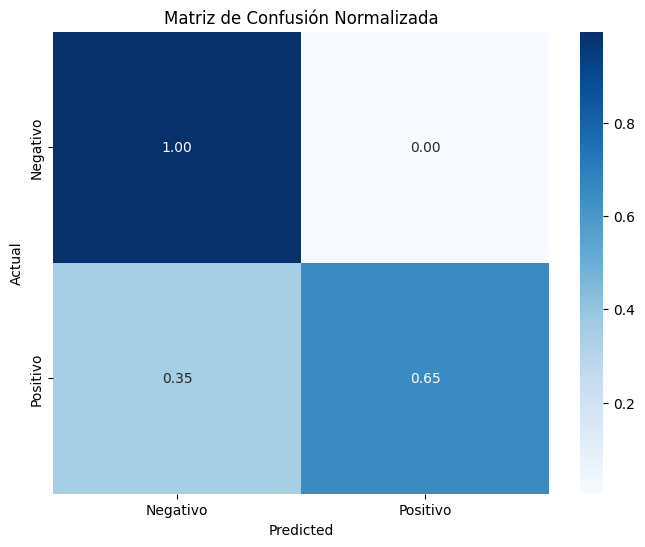

Accuracy: 0.9624
Precision: 0.9391
Recall: 0.6486
F1-score: 0.7673


In [132]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

# Inicialización y entrenamiento del modelo
model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

# Predicciones sobre el conjunto de prueba
y_pred = model.predict(x_test)

# Cálculo de la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Normalizar la matriz de confusión por el total de cada clase (filas)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Visualización de la matriz de confusión normalizada
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión Normalizada')
plt.show()

# Cálculo e impresión de otras métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Matriz de Confusión (relativa en porcentaje):
[[99.71428571  0.28571429]
 [71.47147147 28.52852853]]


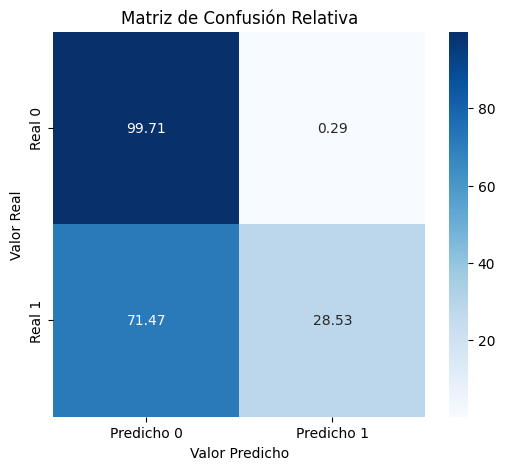


Métricas del modelo:
Accuracy: 0.93
Precision: 0.91
Recall: 0.29
F1-score: 0.43


In [133]:
from sklearn.linear_model import LogisticRegression

# Entrenamiento del modelo
model = LogisticRegression()
model.fit(x_train, y_train)

# Predicción con el conjunto de test
y_pred = model.predict(x_test)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Normalizar la matriz de confusión (porcentajes)
cm_relative = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Imprimir la matriz de confusión relativa
print("Matriz de Confusión (relativa en porcentaje):")
print(cm_relative)

# Visualizar la matriz de confusión con un heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_relative, annot=True, fmt=".2f", cmap="Blues", xticklabels=["Predicho 0", "Predicho 1"], yticklabels=["Real 0", "Real 1"])
plt.title("Matriz de Confusión Relativa")
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.show()

# Métricas adicionales
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Mostrar las métricas
print("\nMétricas del modelo:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
